=== Deep, almost-unrestricted tree ===
Train accuracy: 1.0
Test  accuracy: 0.8787234042553191
Komentaras: train=1.0 ~ stiprus overfitting.

=== Accuracy vs max_depth (first rows) ===
   max_depth  train_acc  test_acc  nodes
0          1   0.634988  0.635461      3
1          2   0.790071  0.790780      7
2          3   0.920095  0.916312     15
3          4   0.925768  0.912057     31
4          5   0.928132  0.912057     57 



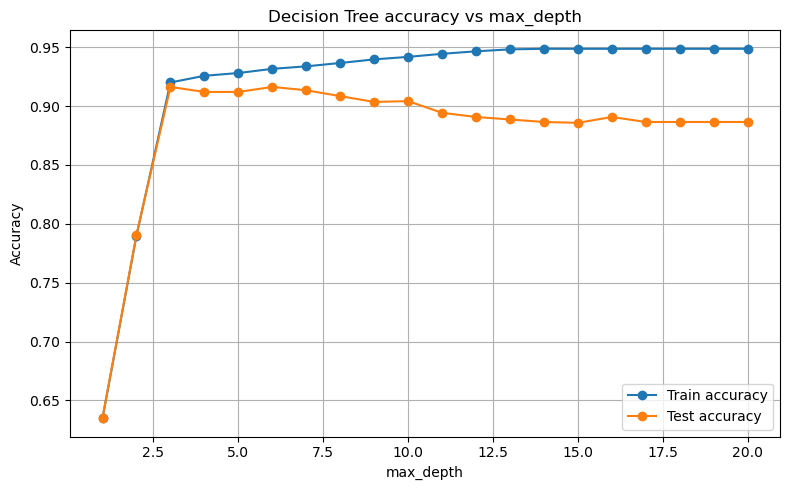

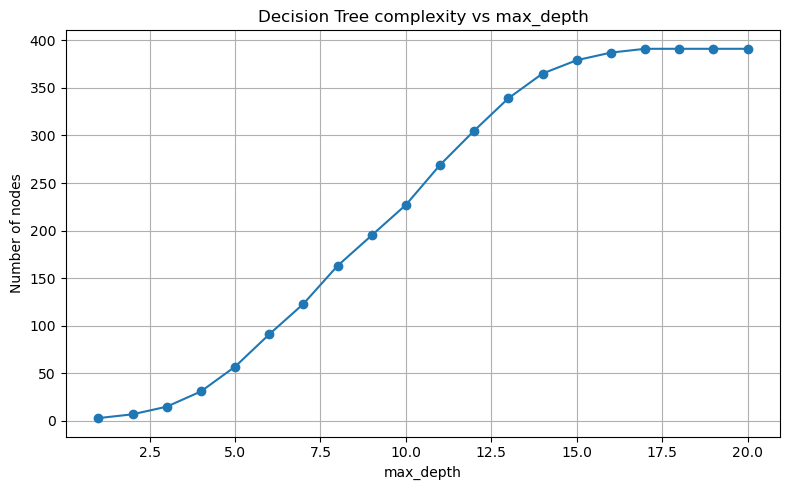

=== Best depth according to test accuracy ===
Best max_depth: 3
Train accuracy at best depth: 0.9200945626477541
Test  accuracy at best depth: 0.9163120567375886 



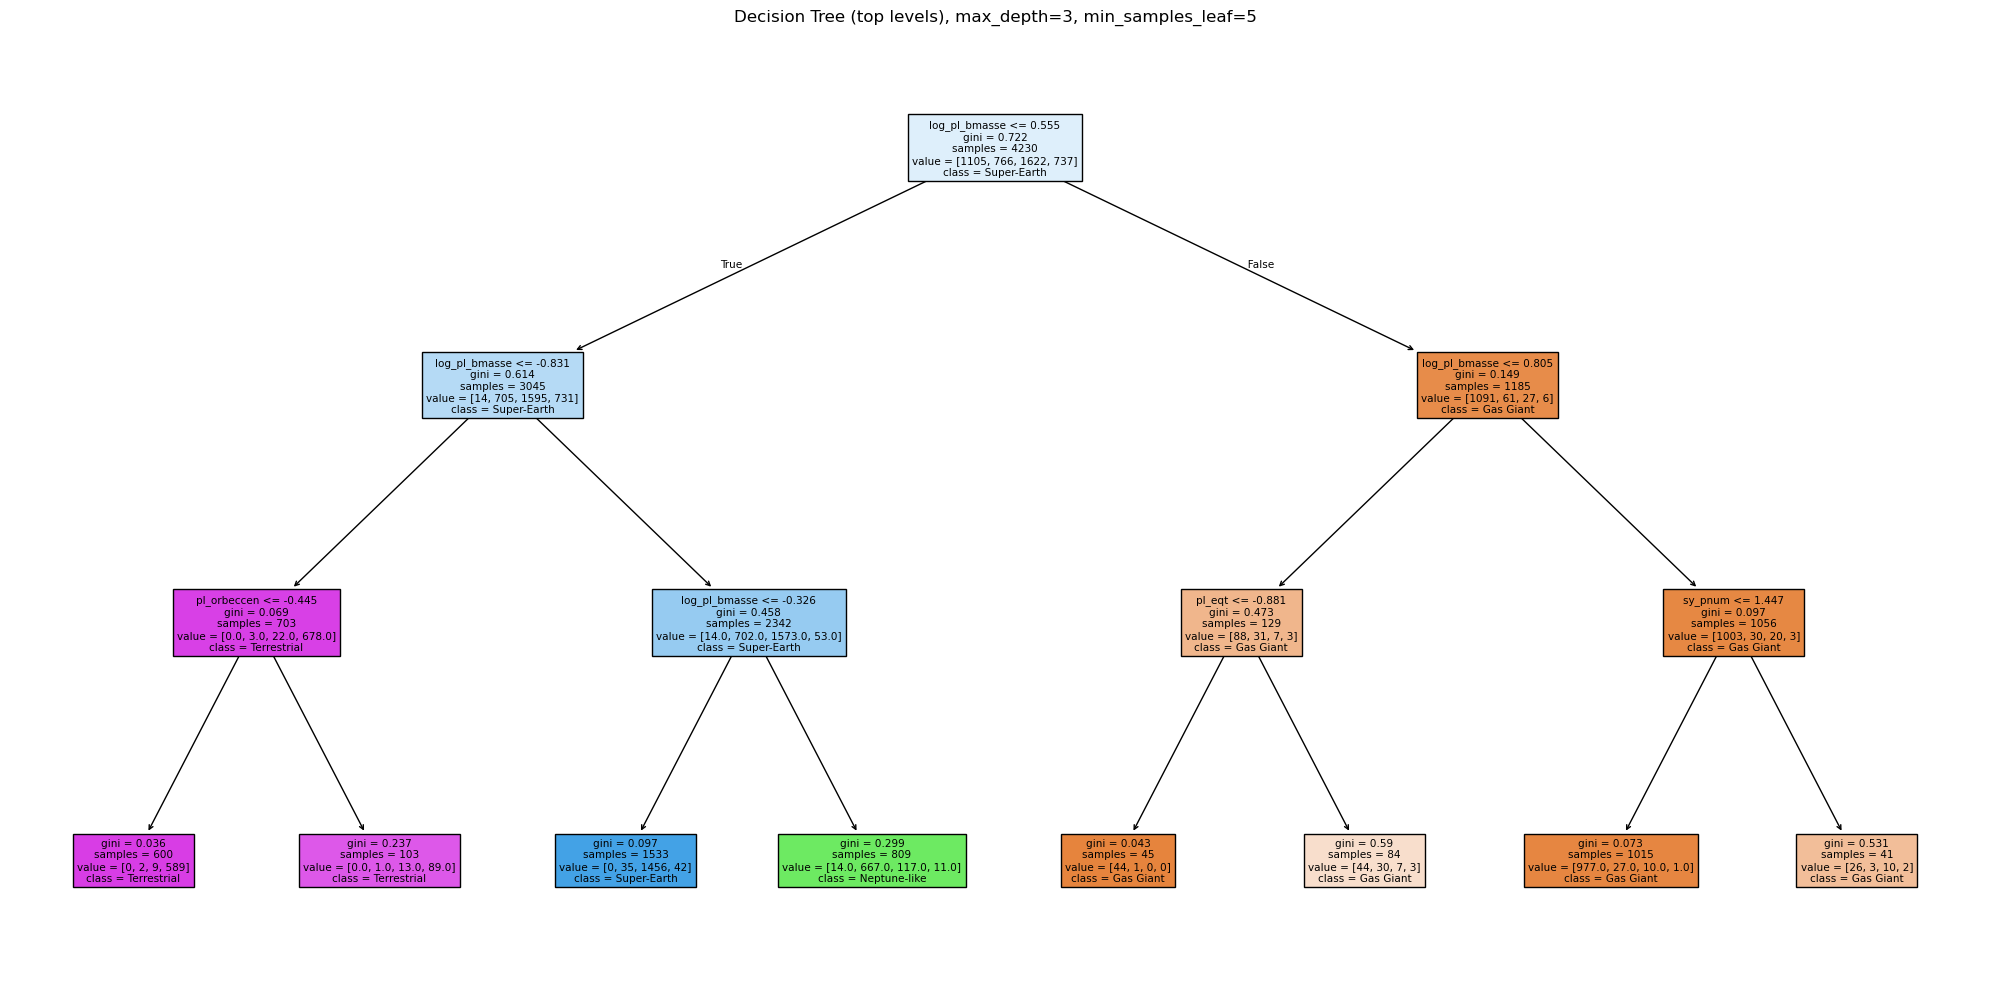

=== Decision rules (truncated) ===
|--- log_pl_bmasse <= 0.56
|   |--- log_pl_bmasse <= -0.83
|   |   |--- pl_orbeccen <= -0.45
|   |   |   |--- class: Terrestrial
|   |   |--- pl_orbeccen >  -0.45
|   |   |   |--- class: Terrestrial
|   |--- log_pl_bmasse >  -0.83
|   |   |--- log_pl_bmasse <= -0.33
|   |   |   |--- class: Super-Earth
|   |   |--- log_pl_bmasse >  -0.33
|   |   |   |--- class: Neptune-like
|--- log_pl_bmasse >  0.56
|   |--- log_pl_bmasse <= 0.81
|   |   |--- pl_eqt <= -0.88
|   |   |   |--- class: Gas Giant
|   |   |--- pl_eqt >  -0.88
|   |   |   |--- class: Gas Giant
|   |--- log_pl_bmasse >  0.81
|   |   |--- sy_pnum <= 1.45
|   |   |   |--- class: Gas Giant
|   |   |--- sy_pnum >  1.45
|   |   |   |--- class: Gas Giant
 

=== Feature importances from decision tree ===
log_pl_bmasse    0.992525
pl_eqt           0.003874
sy_pnum          0.002667
pl_orbeccen      0.000934
st_logg          0.000000
log_pl_orbper    0.000000
log_st_rad       0.000000
dtype: float64 


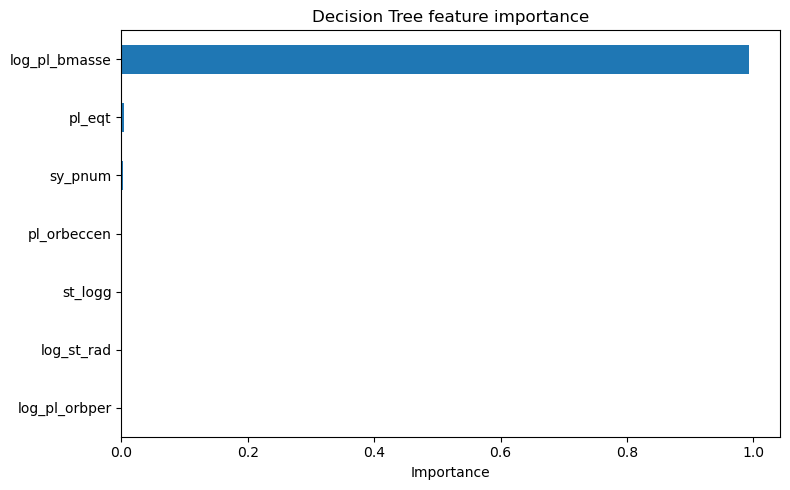

In [3]:
# Q5 – Analyze exoplanet classification rules
# Decision Tree with depth-based pruning / early stopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ----------------------------------------------------
# 1. Duomenų paruošimas (tas pats feature rinkinys kaip Q3/Q4)
# ----------------------------------------------------
df = pd.read_csv("exoplanet.csv")

# log-transformoms reikalingi stulpeliai
for col in ["pl_bmasse", "pl_orbper", "st_rad"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").replace(0, np.nan)

df["log_pl_bmasse"] = np.log(df["pl_bmasse"])
df["log_pl_orbper"] = np.log(df["pl_orbper"])
df["log_st_rad"]    = np.log(df["st_rad"])

feature_cols = [
    "pl_orbeccen",
    "pl_eqt",
    "st_logg",
    "sy_pnum",
    "log_pl_bmasse",
    "log_pl_orbper",
    "log_st_rad",
]

df_model = df[feature_cols + ["planet_class"]].dropna()
df_model[feature_cols] = df_model[feature_cols].fillna(df_model[feature_cols].median())

X = df_model[feature_cols]
y = df_model["planet_class"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ----------------------------------------------------
# 2. Labai gilus medis (overfitting demonstracijai)
# ----------------------------------------------------
deep_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,      # leidžiam medžiui augti kiek nori
    min_samples_leaf=1
)
deep_tree.fit(X_train_s, y_train)

train_acc_deep = deep_tree.score(X_train_s, y_train)
test_acc_deep  = deep_tree.score(X_test_s, y_test)

print("=== Deep, almost-unrestricted tree ===")
print("Train accuracy:", train_acc_deep)
print("Test  accuracy:", test_acc_deep)
print("Komentaras: train=1.0 ~ stiprus overfitting.\n")

# ----------------------------------------------------
# 3. Early stopping per max_depth (pruning parametras)
# ----------------------------------------------------
depths = range(1, 21)   # nuo 1 iki 20
train_scores = []
test_scores = []
node_counts = []

for d in depths:
    clf = DecisionTreeClassifier(
        random_state=42,
        max_depth=d,
        min_samples_leaf=5   # šiek tiek regularizacijos
    )
    clf.fit(X_train_s, y_train)

    train_scores.append(clf.score(X_train_s, y_train))
    test_scores.append(clf.score(X_test_s, y_test))
    node_counts.append(clf.tree_.node_count)

results_depth = pd.DataFrame({
    "max_depth": depths,
    "train_acc": train_scores,
    "test_acc": test_scores,
    "nodes": node_counts
})

print("=== Accuracy vs max_depth (first rows) ===")
print(results_depth.head(), "\n")

# ----------------------------------------------------
# 4. Grafikai: accuracy ir sudėtingumas vs depth
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, test_scores, marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree accuracy vs max_depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(depths, node_counts, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Number of nodes")
plt.title("Decision Tree complexity vs max_depth")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 5. Pasirenkam "geriausią" gylį (max test accuracy)
# ----------------------------------------------------
best_idx   = int(np.argmax(test_scores))
best_depth = depths[best_idx]

print("=== Best depth according to test accuracy ===")
print("Best max_depth:", best_depth)
print("Train accuracy at best depth:", train_scores[best_idx])
print("Test  accuracy at best depth:", test_scores[best_idx], "\n")

best_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=best_depth,
    min_samples_leaf=5
)
best_tree.fit(X_train_s, y_train)

# ----------------------------------------------------
# 6. Vizualizuojam pruned medį (pirmi lygiai)
# ----------------------------------------------------
plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    feature_names=feature_cols,
    class_names=sorted(y.unique()),
    filled=True,
    max_depth=4
)
plt.title(f"Decision Tree (top levels), max_depth={best_depth}, min_samples_leaf=5")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 7. Kelios sprendimo taisyklės (text forma)
# ----------------------------------------------------
rules_text = export_text(best_tree, feature_names=list(feature_cols))
print("=== Decision rules (truncated) ===")
print(rules_text[:1500], "\n")

# ----------------------------------------------------
# 8. Feature importance ir palyginimas su SVM
# ----------------------------------------------------
importances = pd.Series(best_tree.feature_importances_, index=feature_cols)
imp_sorted = importances.sort_values(ascending=False)

print("=== Feature importances from decision tree ===")
print(imp_sorted, "\n")

plt.figure(figsize=(8, 5))
imp_sorted.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Decision Tree feature importance")
plt.tight_layout()
plt.show()
